# 02 — Merge & Dedupe

Stage 2 of 5. Combines the DESI and W2M-current crossmatch outputs from
[01 — Crossmatch](01_crossmatch.ipynb) into a single catalog and removes duplicate rows.

**Pipeline:** [01 — Crossmatch](01_crossmatch.ipynb) → **02 — Merge & Dedupe** →
[03 — UV-Excess Selection](03_uv_excess_selection.ipynb) →
[04 — Visual Review & Final Sample](04_visual_review_final_sample.ipynb) →
[05 — Control Sample](05_control_sample.ipynb)

**Inputs:** `data/matched/DESI_COMBINED_matched.csv`, `data/matched/W2M_COMBINED_matched.csv`

**Output:** `data/matched/FINAL_COMBINED_QSOs_W2M.csv` — the canonical combined catalog used by
every later stage.

**Script reference:** `scripts/matching/combine_catalogs_w2m.py`

Note: the DESI + W2M-**legacy** merge (`scripts/matching/combine_catalogs.py` →
`FINAL_COMBINED_QSOs.csv`) is intentionally not reproduced here — nothing downstream of it
consumes that file; it's a fully superseded branch.

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, unique, vstack

BASE_DIR = Path.cwd().parent
DATA_MATCHED = BASE_DIR / "data" / "matched"
FIGURES_DIR = BASE_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DESI_OUT = DATA_MATCHED / "DESI_COMBINED_matched.csv"
W2M_OUT = DATA_MATCHED / "W2M_COMBINED_matched.csv" 

## Combine + dedupe

Source: `scripts/matching/combine_catalogs_w2m.py`. Stacks the two matched tables (outer join on
columns), then drops duplicate rows using GALEX/UKIDSS magnitude columns as the uniqueness key.

In [2]:
DEDUPE_KEYS = ['FUVmag', 'NUVmag', 'ymag', 'yAperMag3', 'j_1AperMag3', 'hAperMag3', 'kAperMag3']


def combine_and_dedupe(desi_csv, w2m_csv, out_csv):
    desi = Table.read(desi_csv, format='csv')
    w2m = Table.read(w2m_csv, format='csv')

    combined = vstack([desi, w2m], join_type='outer')
    n_before = len(combined)

    # unique() requires no masked values; fill with 0.0 temporarily,
    # then recover original (unmasked) rows by index to avoid propagating fills
    copy = combined.filled(0.0)
    copy['_copy'] = np.arange(len(copy))
    copy = unique(copy, keys=DEDUPE_KEYS)
    combined = combined[copy['_copy']]

    n_dupes = n_before - len(combined)
    combined.write(out_csv, format='csv', overwrite=True)
    print(f"  -> {len(combined)} rows written to {out_csv} ({n_dupes} duplicates removed)")
    return len(desi), len(w2m), n_before, len(combined)


n_desi, n_w2m, n_before, n_after = combine_and_dedupe(
    DESI_OUT, W2M_OUT, DATA_MATCHED / "FINAL_COMBINED_QSOs_W2M.csv"
)

  -> 5489 rows written to /Users/alexgs/Documents/UV_Leakage_Geometry/UV_Leakage_Geometry/data/matched/FINAL_COMBINED_QSOs_W2M.csv (1 duplicates removed)


## Row counts at each step

New diagnostic (no equivalent plot exists in `combine_catalogs_w2m.py`) — makes the effect of
the merge and the dedupe step visible.

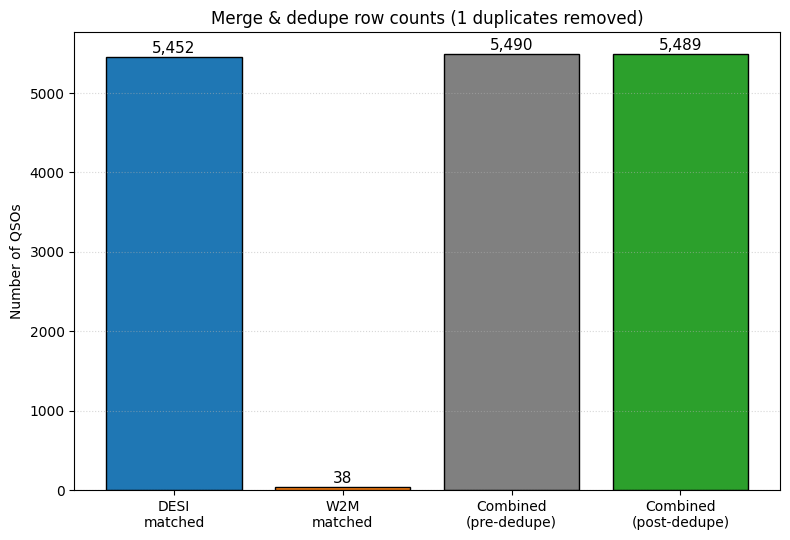

In [3]:
steps = ['DESI\nmatched', 'W2M\nmatched', 'Combined\n(pre-dedupe)', 'Combined\n(post-dedupe)']
counts = [n_desi, n_w2m, n_before, n_after]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(steps, counts, color=['tab:blue', 'tab:orange', 'gray', 'tab:green'], edgecolor='black')
for bar, count in zip(bars, counts):
    ax.annotate(f'{count:,}', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=11)
ax.set_ylabel('Number of QSOs')
ax.set_title(f'Merge & dedupe row counts ({n_before - n_after} duplicates removed)')
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "merge_dedupe_counts.png", dpi=150)
plt.show()